Eigenvalues (stretch amounts): [3. 1.]
Eigenvectors (special directions):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


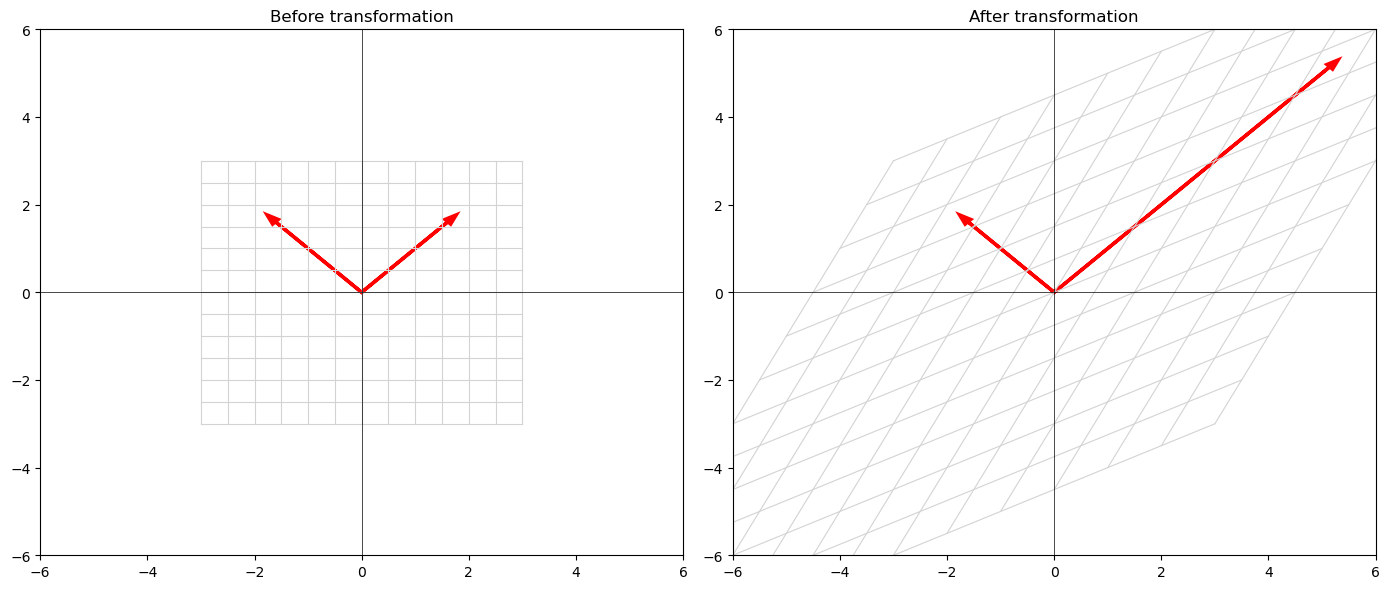

In [27]:

# UNDERSTANDING EIGENVECTORS THROUGH VISUALIZATION
# A transformation matrix stretches/rotates space. Eigenvectors
# are the special directions that only get LONGER or SHORTER -
# they never change direction.

import numpy as np
import matplotlib.pyplot as plt

# STEP 1: Define the transformation
# A "transformation matrix" is just a rule for moving points.
# This 2x2 matrix will stretch and shear (skew) 2D space.
transformation_matrix = np.array([[2, 1],
                                   [1, 2]])

# STEP 2: Find the eigenvectors and eigenvalues
# np.linalg.eig() answers: "Which directions does this
# matrix NOT rotate?"
# eigenvalues  = how much each special direction stretches
# eigenvectors = the special directions themselves (columns)
eigenvalues, eigenvectors = np.linalg.eig(transformation_matrix)

print("Eigenvalues (stretch amounts):", eigenvalues)
print("Eigenvectors (special directions):\n", eigenvectors)

# STEP 3: Build a grid of lines 
line_spacing = np.arange(-3, 3.5, 0.5)      # how many grid lines
points_per_line = np.linspace(-3, 3, 50)    # smoothness of each line

figure, (plot_before, plot_after) = plt.subplots(1, 2, figsize=(14, 6))

# Draw VERTICAL grid lines (fixed x,    y changes along the line)
for fixed_x in line_spacing:
    vertical_line = np.array([np.full_like(points_per_line, fixed_x),
                               points_per_line])
    transformed_line = transformation_matrix @ vertical_line
    plot_before.plot(vertical_line[0], vertical_line[1],
                      color='lightgray', linewidth=0.8)
    plot_after.plot(transformed_line[0], transformed_line[1],
                     color='lightgray', linewidth=0.8)

# Draw HORIZONTAL grid lines (fixed y,   x changes along the line)
for fixed_y in line_spacing:
    horizontal_line = np.array([points_per_line,
                                 np.full_like(points_per_line, fixed_y)])
    transformed_line = transformation_matrix @ horizontal_line
    plot_before.plot(horizontal_line[0], horizontal_line[1],
                      color='lightgray', linewidth=0.8)
    plot_after.plot(transformed_line[0], transformed_line[1],
                     color='lightgray', linewidth=0.8)




# STEP 4: Draw the eigenvectors in red
# These are the ONLY directions that keep pointing the same
# way - they just get longer or shorter.

for i in range(len(eigenvalues)):
    if np.isreal(eigenvalues[i]):  # skip if no real direction exists
        direction = eigenvectors[:, i].real
        stretch_amount = eigenvalues[i].real

        plot_before.arrow(0, 0,
                           direction[0] * 2.5, direction[1] * 2.5,
                           head_width=0.15, color='red', linewidth=2.5,
                           length_includes_head=True)
        plot_after.arrow(0, 0,
                          direction[0] * stretch_amount * 2.5,
                          direction[1] * stretch_amount * 2.5,
                          head_width=0.15, color='red', linewidth=2.5,
                          length_includes_head=True)

# STEP 5: Final formatting
plot_before.set_title("Before transformation")
plot_before.set_xlim(-6, 6);
plot_before.set_ylim(-6, 6)

plot_before.axhline(0, color='black', linewidth=0.5)
plot_before.axvline(0, color='black', linewidth=0.5)
 

plot_after.set_title("After transformation")
plot_after.set_xlim(-6, 6);
plot_after.set_ylim(-6, 6)

plot_after.axhline(0, color='black', linewidth=0.5)
plot_after.axvline(0, color='black', linewidth=0.5)


plt.tight_layout()
plt.savefig('eigenvector_transformation.png', dpi=150)
plt.show()
